# Astronomy Supervised

This example demonstrates a supervised astronomy workflow for classifying astronomical transients
from their multi-band light curves.

<div class="admonition note">
<p class="admonition-title">Note</p>
<p>This notebook is intentionally slightly more involved than the <a href="getting_started.html">Hello World</a>
and <a href="unsupervised_image_extragalactic.html">Astronomy Unsupervised</a> examples. In this example, we define a <b>custom dataset class</b> and a <b>custom model</b> for 1-D light-curve data. If you are new to Hyrax, we recommend working through those earlier
examples first.</p>
</div>

## Overview

The workflow is:

- Download the PLAsTiCC light-curve dataset from the Multi-Modal Universe project
- Preprocess the variable-length, irregularly sampled light curves into per-observation sequences
- Define a custom Hyrax dataset (with a custom collate function for variable-length padding) and a GRU-based recurrent model
- Train the classifier with class-weighted loss to handle PLAsTiCC's severe class imbalance
- Predict transient classes on held-out test data
- Evaluate performance with a confusion matrix

The [PLAsTiCC challenge](https://plasticc.org/) was a major Kaggle
competition for photometric transient classification on simulated LSST light curves.
The winning solution, [AVOCADO](https://arxiv.org/abs/1907.04690), used
Gaussian Process interpolation followed by a gradient-boosted tree. Several other top-placing
teams — including the 2nd-place solution — used recurrent neural networks (GRUs and LSTMs)
on the raw observation sequences.

We follow this RNN-based approach here because it maps naturally onto Hyrax's dataset and
model APIs and demonstrates how to handle **variable-length, irregularly sampled time series**
without any interpolation or binning. GRUs process observations sequentially and encode the
time gap between observations as an explicit input feature.

## The data

This example uses the [PLAsTiCC](https://plasticc.org/) training set as reformatted by the
[Multi-Modal Universe](https://github.com/MultimodalUniverse/MultimodalUniverse) (MMU) project.
It contains roughly 7,800 labeled light curves across 14 classes of astronomical transients
and variables — including SNIa, SNII, SNIbc, TDE, AGN, RR Lyrae, kilonova, and more.
Each light curve has multi-band photometry (LSST *ugrizY*) with irregular cadence.

## The model

We define a GRU (Gated Recurrent Unit) recurrent neural network that processes each light
curve as a variable-length sequence of observations. Each observation is represented as a
feature vector containing the time elapsed since the previous observation, the flux, the
flux uncertainty, and a one-hot encoding of the photometric band. This approach naturally
handles irregular cadence and variable-length sequences — unlike a CNN, the GRU does not
require binning or interpolation, so no temporal information is lost.

## Install dependencies

We need Hyrax and the HuggingFace `datasets` library to download the MMU data.
You can skip this step if these are already installed in your environment.

In [ ]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.


## Download the PLAsTiCC dataset

We load the PLAsTiCC training set directly from the MMU HuggingFace repository.
The download is roughly 15 MB.

In [2]:
from datasets import load_dataset

ds = load_dataset("MultimodalUniverse/plasticc", split="train")

print(f"Loaded {len(ds)} samples")
print(f"\nFeatures: {list(ds.features.keys())}")
print(f"\nFirst sample keys: {list(ds[0].keys())}")
print(f"Light curve keys:  {list(ds[0]['lightcurve'].keys())}")

Loaded 7848 samples

Features: ['lightcurve', 'hostgal_photoz', 'hostgal_specz', 'redshift', 'obj_type', 'object_id']

First sample keys: ['lightcurve', 'hostgal_photoz', 'hostgal_specz', 'redshift', 'obj_type', 'object_id']
Light curve keys:  ['band', 'flux', 'flux_err', 'time']


## Preprocess light curves

The raw light curves have variable lengths and irregular cadence across six LSST bands.
Instead of binning into a fixed grid (which destroys temporal structure), we keep every
observation and represent it as a feature vector that a recurrent model can consume directly.

For each object we:
1. Filter out zero-padded placeholder observations
2. Sort all observations chronologically (across all bands)
3. Compute the time elapsed since the previous observation (delta-t)
4. Normalize flux per object
5. One-hot encode the photometric band

This produces a variable-length sequence of 9-dimensional feature vectors per object:
`(delta_t, flux, flux_err, u, g, r, i, z, Y)`.

In [3]:
import numpy as np
from pathlib import Path

# LSST band names in wavelength order → channel indices
BAND_TO_IDX = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "Y": 5}
NUM_BANDS = len(BAND_TO_IDX)
INPUT_DIM = 1 + 1 + 1 + NUM_BANDS  # delta_t, flux, flux_err, 6 band one-hots = 9


def extract_sequence(lc):
    """Convert a variable-length multi-band light curve into a feature sequence.

    Returns an (N_obs, 9) float32 array where each row is
    (delta_t, flux, flux_err, u, g, r, i, z, Y).
    """
    band_strs = np.asarray(lc["band"])
    times = np.asarray(lc["time"], dtype=np.float64)
    fluxes = np.asarray(lc["flux"], dtype=np.float32)
    flux_errs = np.asarray(lc["flux_err"], dtype=np.float32)

    # The MMU PLAsTiCC format zero-pads unused observation slots.
    real = (times > 0) | (fluxes != 0)
    band_strs, times, fluxes, flux_errs = (
        band_strs[real],
        times[real],
        fluxes[real],
        flux_errs[real],
    )

    if len(times) == 0:
        return np.zeros((1, INPUT_DIM), dtype=np.float32)

    # Sort chronologically
    order = np.argsort(times)
    band_strs, times, fluxes, flux_errs = (
        band_strs[order],
        times[order],
        fluxes[order],
        flux_errs[order],
    )

    # Delta-t: time since previous observation (first obs gets 0)
    delta_t = np.zeros(len(times), dtype=np.float32)
    delta_t[1:] = np.diff(times).astype(np.float32)
    # Normalize delta_t to [0, 1]
    dt_max = delta_t.max()
    if dt_max > 0:
        delta_t /= dt_max

    # Normalize flux per object
    max_abs = np.abs(fluxes).max()
    if max_abs > 0:
        fluxes /= max_abs
        flux_errs /= max_abs

    # One-hot band encoding
    band_onehot = np.zeros((len(times), NUM_BANDS), dtype=np.float32)
    for j, bs in enumerate(band_strs):
        idx = BAND_TO_IDX.get(str(bs), -1)
        if idx >= 0:
            band_onehot[j, idx] = 1.0

    # Stack into (N_obs, 9) feature matrix
    seq = np.column_stack([delta_t, fluxes, flux_errs, band_onehot])
    return seq.astype(np.float32)


# --- Process every sample ---
all_seqs, all_raw_labels = [], []
for sample in ds:
    all_seqs.append(extract_sequence(sample["lightcurve"]))
    all_raw_labels.append(sample["obj_type"])

# Map string labels to contiguous integers
unique_classes = sorted(set(all_raw_labels))
label_to_idx = {c: i for i, c in enumerate(unique_classes)}
idx_to_name = {i: c for i, c in enumerate(unique_classes)}
labels = np.array([label_to_idx[l] for l in all_raw_labels])

seq_lengths = [len(s) for s in all_seqs]
print(f"Preprocessed {len(all_seqs)} light curves")
print(
    f"Sequence lengths: min={min(seq_lengths)}, median={int(np.median(seq_lengths))}, max={max(seq_lengths)}"
)
print(f"Feature dim: {INPUT_DIM}")
print(f"\nClasses: {len(unique_classes)}")
for i, name in idx_to_name.items():
    count = (labels == i).sum()
    print(f"  {i:>2d}: {name} ({count} samples)")

# --- Compute class weights (inverse frequency) for weighted loss ---
class_counts = np.bincount(labels)
class_weights = len(labels) / (len(unique_classes) * class_counts)
class_weights = class_weights.astype(np.float32)
print(f"\nClass weights: {dict(zip(idx_to_name.values(), class_weights.round(2)))}")

# --- 80/20 stratified train/test split ---
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

data_dir = Path("./data/plasticc")
data_dir.mkdir(parents=True, exist_ok=True)

# Save sequences as object arrays (variable length) + labels + class weights
np.savez(
    data_dir / "train.npz",
    sequences=np.array([all_seqs[i] for i in train_idx], dtype=object),
    labels=labels[train_idx],
    object_ids=train_idx,
    class_weights=class_weights,
)
np.savez(
    data_dir / "test.npz",
    sequences=np.array([all_seqs[i] for i in test_idx], dtype=object),
    labels=labels[test_idx],
    object_ids=test_idx,
)

print(f"\nSaved {len(train_idx)} train / {len(test_idx)} test samples to {data_dir}")

Preprocessed 7848 light curves
Sequence lengths: min=34, median=100, max=296
Feature dim: 9

Classes: 14
   0: AGN (370 samples)
   1: EB (924 samples)
   2: KN (102 samples)
   3: M-dwarf (981 samples)
   4: MicroLens-Single (151 samples)
   5: Mira (30 samples)
   6: RRL (239 samples)
   7: SLSN-I (175 samples)
   8: SNII (1193 samples)
   9: SNIa (2313 samples)
  10: SNIa-91bg (208 samples)
  11: SNIax (183 samples)
  12: SNIbc (484 samples)
  13: TDE (495 samples)

Class weights: {'AGN': np.float32(1.52), 'EB': np.float32(0.61), 'KN': np.float32(5.5), 'M-dwarf': np.float32(0.57), 'MicroLens-Single': np.float32(3.71), 'Mira': np.float32(18.69), 'RRL': np.float32(2.35), 'SLSN-I': np.float32(3.2), 'SNII': np.float32(0.47), 'SNIa': np.float32(0.24), 'SNIa-91bg': np.float32(2.7), 'SNIax': np.float32(3.06), 'SNIbc': np.float32(1.16), 'TDE': np.float32(1.13)}

Saved 6278 train / 1570 test samples to data/plasticc



Saved 6278 train / 1570 test samples to data/plasticc


Let's visualize a few example light-curve sequences. Each point is a single observation,
colored by band, and plotted at its actual observation time — no binning or interpolation.

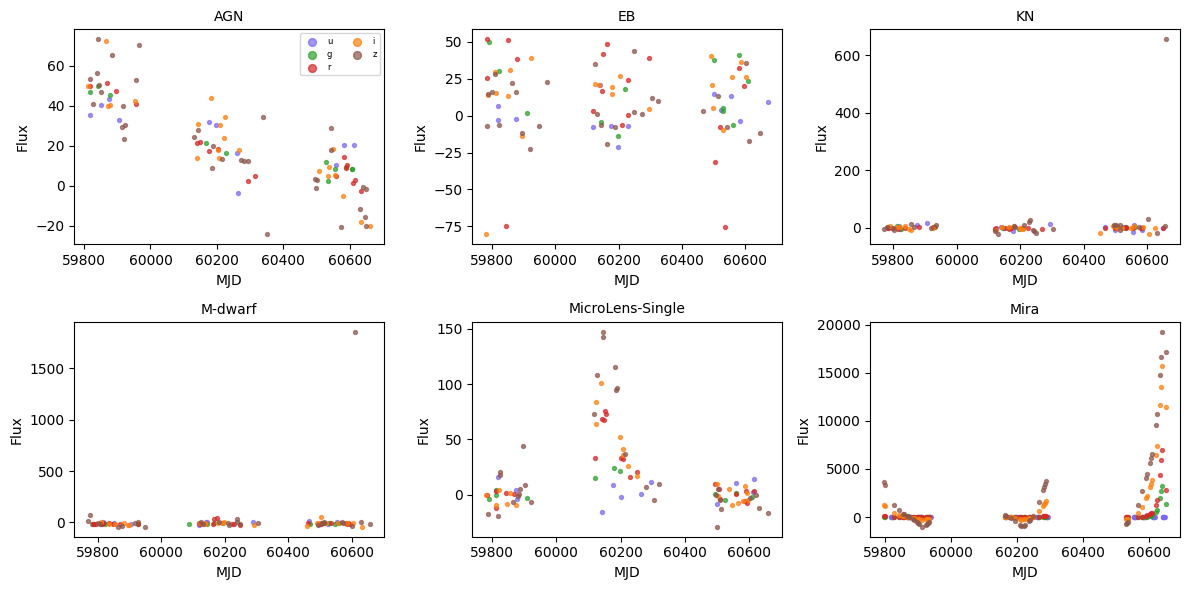

In [4]:
import matplotlib.pyplot as plt

BAND_NAMES = list(BAND_TO_IDX.keys())
band_colors = {"u": "#7B68EE", "g": "#2ca02c", "r": "#d62728", "i": "#ff7f0e", "z": "#8c564b", "Y": "#1f77b4"}

show_classes = list(range(min(6, len(idx_to_name))))
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, cls in zip(axes.flat, show_classes):
    sample_idx = np.where(labels == cls)[0][0]
    lc = ds[int(sample_idx)]["lightcurve"]

    band_strs = np.asarray(lc["band"])
    times = np.asarray(lc["time"], dtype=np.float64)
    fluxes = np.asarray(lc["flux"], dtype=np.float32)
    real = (times > 0) | (fluxes != 0)

    for band_name in BAND_NAMES:
        mask = real & (band_strs == band_name)
        if mask.any():
            ax.scatter(
                times[mask],
                fluxes[mask],
                label=band_name,
                c=band_colors[band_name],
                s=8,
                alpha=0.7,
            )
    ax.set_title(idx_to_name[cls], fontsize=10)
    ax.set_xlabel("MJD")
    ax.set_ylabel("Flux")

axes[0, 0].legend(fontsize=6, ncol=2, markerscale=2)
plt.tight_layout()
plt.show()

## Define a custom dataset

To use preprocessed data with Hyrax we subclass `HyraxDataset`.
A dataset needs to implement:
- `__len__` — the number of samples
- `get_<field>(idx)` methods for each field the model will consume

Because our light-curve sequences have variable lengths, we also define a `collate`
method. Hyrax automatically detects this method and uses it instead of the default
numpy-stacking collation. Our collate pads all sequences in a batch to the same length
and returns the true sequence lengths so the model can use `pack_padded_sequence`.

In [5]:
from hyrax.datasets import HyraxDataset


class PLAsTiCCSequenceDataset(HyraxDataset):
    """Hyrax dataset for variable-length PLAsTiCC light-curve sequences."""

    def __init__(self, config: dict, data_location=None):
        data_dir = Path(data_location)

        # Pick train or test split based on config
        ds_config = config.get("data_set", {}).get("PLAsTiCCSequenceDataset", {})
        split = "train" if ds_config.get("use_training_data", True) else "test"

        data = np.load(data_dir / f"{split}.npz", allow_pickle=True)
        self.sequences = data["sequences"]  # object array of (seq_len, 9) arrays
        self.labels = data["labels"]
        self.object_ids = data["object_ids"]

        # Store class weights if available (training split only)
        self.class_weights = data["class_weights"] if "class_weights" in data else None

        super().__init__(config)

    def get_sequence(self, idx):
        """Return the feature sequence for one object — shape (seq_len, 9)."""
        return np.array(self.sequences[idx], dtype=np.float32)

    def get_label(self, idx):
        """Return the integer class label."""
        return int(self.labels[idx])

    def get_object_id(self, idx):
        """Return a unique string identifier."""
        return str(self.object_ids[idx])

    def __len__(self):
        return len(self.labels)

    def collate(self, samples: list[dict]) -> dict:
        """Pad variable-length sequences to the max length in the batch.

        Parameters
        ----------
        samples
            List of dicts, each with keys like ``"sequence"`` and ``"label"``.

        Returns
        -------
        dict
            ``"sequence"`` — float32 array (batch, max_len, 9), zero-padded
            ``"label"`` — int64 array (batch,)
            ``"lengths"`` — int64 array (batch,) with true sequence lengths
        """
        seqs = [s["sequence"] for s in samples]
        lengths = np.array([len(s) for s in seqs], dtype=np.int64)
        max_len = int(lengths.max())

        padded = np.zeros((len(seqs), max_len, seqs[0].shape[-1]), dtype=np.float32)
        for i, s in enumerate(seqs):
            padded[i, : len(s)] = s

        result = {"sequence": padded, "lengths": lengths}

        # Labels are present during training but not inference
        if "label" in samples[0]:
            result["label"] = np.array([s["label"] for s in samples], dtype=np.int64)

        return result

## Define a custom model

We use a bidirectional GRU that processes the padded observation sequences using
PyTorch's `pack_padded_sequence` / `pad_packed_sequence` to efficiently skip
padding positions. The final hidden states from both directions are concatenated
and passed through a classification head.

The model also sets its own loss function (`self.criterion`) with class weights
computed from the training data. Hyrax's `@hyrax_model` decorator detects this
and uses it instead of loading a criterion from the config.

In [6]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from hyrax.models import hyrax_model


@hyrax_model
class LightCurveGRU(nn.Module):
    """A bidirectional GRU for variable-length multi-band light-curve classification."""

    def __init__(self, config, data_sample=None):
        super().__init__()
        self.config = config
        model_config = config["model"]["LightCurveGRU"]

        input_dim = model_config.get("input_dim", INPUT_DIM)
        hidden_size = model_config.get("hidden_size", 128)
        num_layers = model_config.get("num_layers", 2)
        dropout = model_config.get("dropout", 0.3)
        num_classes = model_config["output_classes"]
        self.grad_clip = model_config.get("grad_clip", 1.0)

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # Bidirectional → 2x hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

        # Set class-weighted loss before @hyrax_model wiring runs
        cw = model_config.get("class_weights", None)
        if cw is not None:
            weight = torch.tensor(cw, dtype=torch.float32)
            self.criterion = nn.CrossEntropyLoss(weight=weight)

    def forward(self, x):
        sequences, labels, lengths = x

        # pack_padded_sequence needs lengths on CPU
        lengths_cpu = lengths.cpu()

        packed = pack_padded_sequence(
            sequences,
            lengths_cpu,
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.gru(packed)
        # hidden shape: (num_layers * 2, batch, hidden_size)
        # Concatenate final forward and backward hidden states
        fwd = hidden[-2]  # last layer, forward
        bwd = hidden[-1]  # last layer, backward
        combined = torch.cat([fwd, bwd], dim=-1)  # (batch, hidden_size * 2)

        return self.classifier(combined)

    def train_batch(self, batch):
        _, labels, _ = batch
        self.optimizer.zero_grad()
        outputs = self(batch)
        loss = self.criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(self.parameters(), self.grad_clip)
        self.optimizer.step()
        return {"loss": loss.item()}

    def validate_batch(self, batch):
        _, labels, _ = batch
        outputs = self(batch)
        loss = self.criterion(outputs, labels)
        return {"loss": loss.item()}

    def test_batch(self, batch):
        return self.validate_batch(batch)

    def infer_batch(self, batch):
        return self(batch)

    @staticmethod
    def prepare_inputs(data_dict):
        """Convert the collated data dictionary to numpy arrays."""
        import numpy as np

        data = data_dict["data"]
        sequence = np.asarray(data["sequence"], dtype=np.float32)
        lengths = np.asarray(data["lengths"], dtype=np.int64)
        label = np.asarray(data.get("label", np.zeros(len(lengths))), dtype=np.int64)
        return (sequence, label, lengths)

## Initialize Hyrax and configure

From here the workflow is the same as any other Hyrax example: create a `Hyrax` instance,
point it at our custom model and dataset, and run verbs.

In [ ]:
from hyrax import Hyrax

h = Hyrax()

h.set_config("model.name", "LightCurveGRU")

# Create the config section for our custom model. We pass the class weights
# so the model can build a weighted CrossEntropyLoss in its __init__.
h.config["model"]["LightCurveGRU"] = {
    "output_classes": len(idx_to_name),
    "input_dim": INPUT_DIM,
    "hidden_size": 256,
    "num_layers": 2,
    "dropout": 0.3,
    "grad_clip": 1.0,
    "class_weights": class_weights.tolist(),
}

# Adam is the standard optimizer for RNNs — SGD struggles with recurrent gradients
h.set_config("optimizer.name", "torch.optim.Adam")
h.config["torch.optim.Adam"] = {"lr": 1e-3}

h.set_config("data_loader.batch_size", 64)
h.set_config("train.epochs", 50)

## Define the dataset and train

We configure the `data_request` to use our custom `PLAsTiCCSequenceDataset` and request
the `sequence` and `label` fields. Note how the field names match the `get_sequence`
and `get_label` methods we defined above. Because our dataset defines a `collate`
method, Hyrax will automatically use it to pad variable-length sequences in each batch.

In [ ]:
data_request_definition = {
    "train": {
        "data": {
            "dataset_class": "PLAsTiCCSequenceDataset",
            "data_location": "./data/plasticc",
            "fields": ["sequence", "label"],
            "primary_id_field": "object_id",
            "split_fraction": 1.0,
        },
    },
}

h.set_config("data_request", data_request_definition)

trained_model = h.train()

2026/03/27 23:27:30 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[2026-03-27 23:27:30,887 hyrax.verbs.train:INFO] Finished Training


INFO  [hyrax.verbs.train] Finished Training


## Predict with the model

We now classify the held-out test light curves. Setting `use_training_data` to `False`
via `dataset_config` tells our dataset to load `test.npz` instead of `train.npz`.

For custom datasets the `dataset_config` dictionary must be nested under the dataset
class name so that Hyrax knows which config section to update.

In [ ]:
data_request_definition["infer"] = {
    "data": {
        "dataset_class": "PLAsTiCCSequenceDataset",
        "data_location": "./data/plasticc",
        "fields": ["sequence", "object_id"],
        "primary_id_field": "object_id",
        "dataset_config": {
            "PLAsTiCCSequenceDataset": {
                "use_training_data": False,
            },
        },
    },
}

h.set_config("data_request", data_request_definition)

inference_results = h.infer()

[2026-03-27 23:27:31,020 hyrax.verbs.infer:INFO] Inference dataset(s):
{'infer': Name: data (primary dataset)
  Dataset class: PLAsTiCCSequenceDataset
  Data location: /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/data/plasticc
  Primary ID field: object_id
  Requested fields: sequence, object_id
  Dataset config:
    PLAsTiCCSequenceDataset: {'use_training_data': False}
}


INFO  [hyrax.verbs.infer] Inference dataset(s):
{'infer': Name: data (primary dataset)
  Dataset class: PLAsTiCCSequenceDataset
  Data location: /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/data/plasticc
  Primary ID field: object_id
  Requested fields: sequence, object_id
  Dataset config:
    PLAsTiCCSequenceDataset: {'use_training_data': False}
}


2026-03-27 23:27:31,021 ignite.distributed.auto.auto_dataloader INFO: Use data loader kwargs for dataset 'Name: data (primary': 
	{'sampler': None, 'batch_size': 64, 'shuffle': False, 'collate_fn': <bound method DataProvider.collate of Name: data (primary dataset)
  Dataset class: PLAsTiCCSequenceDataset
  Data location: /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/data/plasticc
  Primary ID field: object_id
  Requested fields: sequence, object_id
  Dataset config:
    PLAsTiCCSequenceDataset: {'use_training_data': False}
>, 'pin_memory': True}


[2026-03-27 23:27:31,039 hyrax.models.model_utils:INFO] Updated config['infer']['model_weights_file'] to: /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/results/20260327-232400-train-QJlv/example_model.pth


INFO  [hyrax.models.model_utils] Updated config['infer']['model_weights_file'] to: /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/results/20260327-232400-train-QJlv/example_model.pth


...

INFO  [hyrax.datasets.result_dataset] Optimizing Lance table after 25 batches


[2026-03-27 23:27:31,876 hyrax.datasets.result_dataset:INFO] Lance table optimization complete


INFO  [hyrax.datasets.result_dataset] Lance table optimization complete


[2026-03-27 23:27:31,877 hyrax.verbs.infer:INFO] Inference Complete.


INFO  [hyrax.verbs.infer] Inference Complete.


## Evaluate the performance

The model outputs a 14-element vector per light curve. The index of the maximum value
is the predicted class. We compare against the true labels and display a confusion matrix.

Accuracy: 70.89%


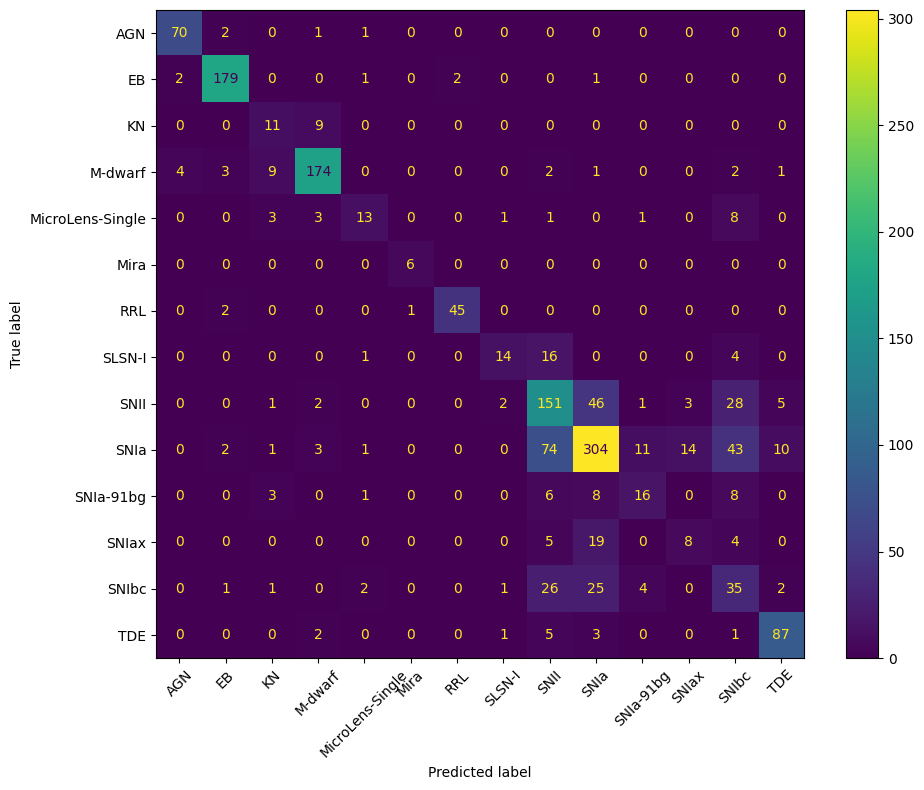

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predicted classes
y_pred = [inference_results[i].argmax() for i in range(len(inference_results))]

# True labels from saved test split
test_data = np.load("./data/plasticc/test.npz")
y_true = test_data["labels"].tolist()

correct = sum(t == p for t, p in zip(y_true, y_pred))
print(f"Accuracy: {correct / len(y_true):.2%}")

class_names = [idx_to_name[i] for i in range(len(idx_to_name))]

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.tight_layout()
plt.show()

The GRU achieves roughly **71-72%** accuracy on 14 classes; but  the PLAsTiCC Kaggle competition winners achieved much higher performance by combining Gaussian Process interpolation, hand-crafted features, and gradient-boosted trees. The goal of this notebook is not to compete with those results, but to show how Hyrax's model and dataset APIs can be used to build a recurrent classifier from scratch on time-series data. 

## What to take away

1. **Hyrax is not limited to images.** By defining a custom dataset and model, you can
   work with light curves, spectra, or any other data modality.
2. **Custom datasets** subclass `HyraxDataset` and provide `get_<field>()` methods.
   For variable-length data, define a `collate` method — Hyrax will detect and use it
   automatically.
3. **Custom models** are standard `torch.nn.Module` classes decorated with `@hyrax_model`.
   Implement `train_batch`, `infer_batch`, and `prepare_inputs`, and Hyrax handles the rest.
   You can set `self.criterion` directly in `__init__` to use a custom loss (e.g., class-weighted).
5. **The core Hyrax workflow is the same** regardless of data type: configure → train → infer → evaluate.